# Diarization Error Rate (DER) Analysis

Computes DER between hypothesis (`identity_stitched.rttm`) and ground truth (`ground_truth.rttm`), then visualizes differences.

In [11]:
from pyannote.core import Annotation, Segment
from pyannote.metrics.diarization import DiarizationErrorRate
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import re
from pathlib import Path

In [12]:
HYPOTHESIS_RTTM = Path("../data/test/identity_stitched.rttm")
REFERENCE_RTTM  = Path("../data/test/ground_truth.rttm")
COLLAR = 0.25  # seconds — common choice; set to 0.0 for strict

## Load RTTM files

In [13]:
def load_rttm(path: Path) -> Annotation:
    """Parse an RTTM file into a single Annotation (ignores the file_id column)."""
    ann = Annotation(uri=path.stem)
    with open(path) as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith(";"):
                continue
            parts = re.split(r"\s+", line)
            # RTTM format: TYPE FILE CHANNEL ONSET DURATION <NA> <NA> SPEAKER <NA> <NA>
            if parts[0] != "SPEAKER":
                continue
            onset    = float(parts[3])
            duration = float(parts[4])
            speaker  = parts[7]
            ann[Segment(onset, onset + duration)] = speaker
    return ann


ref = load_rttm(REFERENCE_RTTM)
hyp = load_rttm(HYPOTHESIS_RTTM)

print(f"Reference speakers : {sorted(ref.labels())}")
print(f"Hypothesis speakers: {sorted(hyp.labels())}")
print(f"Reference duration : {ref.get_timeline().extent().duration:.1f}s")
print(f"Hypothesis duration: {hyp.get_timeline().extent().duration:.1f}s")

Reference speakers : ['FEE013', 'FEE016', 'MEE014', 'MEO015']
Hypothesis speakers: ['FEE013', 'FEE016', 'MEE014', 'MEO015']
Reference duration : 1049.0s
Hypothesis duration: 1036.6s


## Compute DER

In [14]:
metric = DiarizationErrorRate(collar=COLLAR)
components = metric(ref, hyp, detailed=True)

total = components["total"]
der   = components["diarization error rate"]
miss  = components["missed detection"] / total if total else 0
fa    = components["false alarm"]      / total if total else 0
conf  = components["confusion"]        / total if total else 0

print(f"\n{'Metric':<25}  {'Value':>8}")
print("-" * 36)
print(f"{'DER':<25}  {der:>8.3f}")
print(f"{'Missed detection':<25}  {miss:>8.3f}")
print(f"{'False alarm':<25}  {fa:>8.3f}")
print(f"{'Confusion':<25}  {conf:>8.3f}")
print(f"{'Total ref speech (s)':<25}  {total:>8.1f}")


Metric                        Value
------------------------------------
DER                           0.396
Missed detection              0.225
False alarm                   0.079
Confusion                     0.091
Total ref speech (s)          796.1


/home/eriksalt/proj/session_summarizer/.venv/lib/python3.12/site-packages/pyannote/metrics/utils.py:200: UserWarning: 'uem' was approximated by the union of 'reference' and 'hypothesis' extents.
  warnings.warn(


## Visualize DER components per file

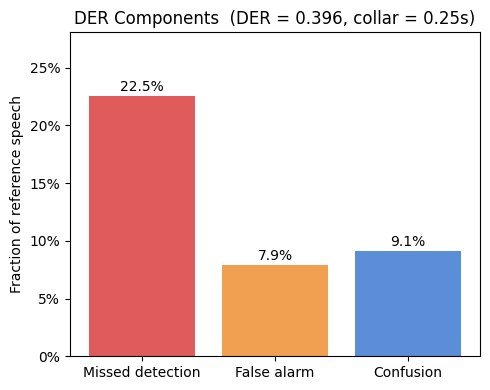

In [15]:
fig, ax = plt.subplots(figsize=(5, 4))

labels = ["Missed detection", "False alarm", "Confusion"]
values = [miss, fa, conf]
colors = ["#e05c5c", "#f0a050", "#5b8dd9"]

bars = ax.bar(labels, values, color=colors)
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.002,
            f"{val:.1%}", ha="center", va="bottom", fontsize=10)

ax.set_ylabel("Fraction of reference speech")
ax.set_title(f"DER Components  (DER = {der:.3f}, collar = {COLLAR}s)")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
ax.set_ylim(0, max(values) * 1.2 + 0.01)
plt.tight_layout()
plt.show()

## Timeline visualization — reference vs hypothesis (one file)

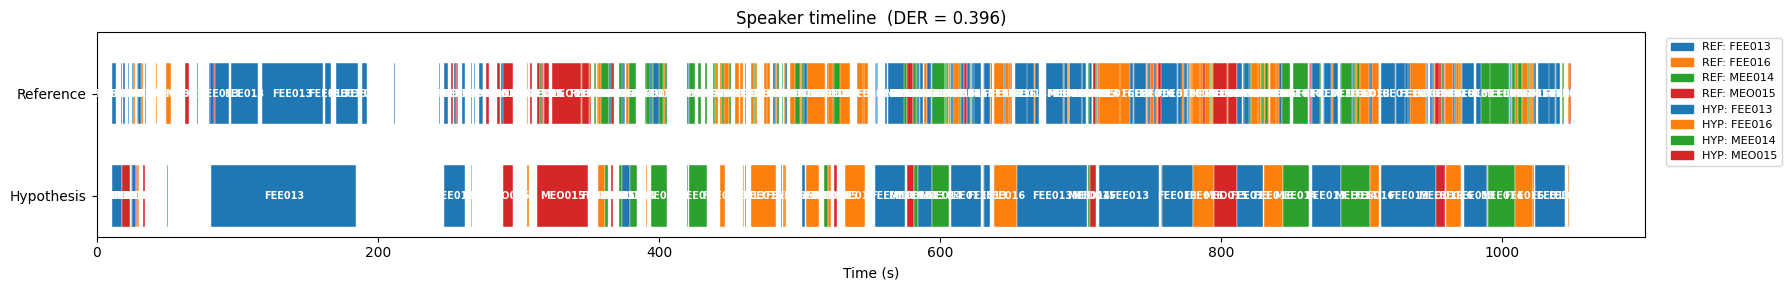

In [16]:
# Build colour maps per annotation
def make_color_map(annotation):
    speakers = sorted(annotation.labels())
    palette  = plt.cm.tab10.colors
    return {spk: palette[i % len(palette)] for i, spk in enumerate(speakers)}

ref_colors = make_color_map(ref)
hyp_colors = make_color_map(hyp)

def draw_annotation(ax, annotation, color_map, row_y):
    for segment, _, speaker in annotation.itertracks(yield_label=True):
        ax.barh(row_y, segment.duration, left=segment.start, height=0.6,
                color=color_map[speaker], edgecolor="white", linewidth=0.3)
        if segment.duration > 1.0:
            ax.text(segment.start + segment.duration / 2, row_y,
                    speaker, ha="center", va="center", fontsize=7, color="white",
                    fontweight="bold", clip_on=True)

fig, ax = plt.subplots(figsize=(18, 3))
draw_annotation(ax, ref, ref_colors, 1)
draw_annotation(ax, hyp, hyp_colors, 0)

ax.set_yticks([0, 1])
ax.set_yticklabels(["Hypothesis", "Reference"])

patches = [mpatches.Patch(color=c, label=f"REF: {s}") for s, c in ref_colors.items()]
patches += [mpatches.Patch(color=c, label=f"HYP: {s}") for s, c in hyp_colors.items()]
ax.legend(handles=patches, bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)

ax.set_xlabel("Time (s)")
ax.set_title(f"Speaker timeline  (DER = {der:.3f})")
ax.set_ylim(-0.4, 1.6)
plt.tight_layout()
plt.show()

## Error timeline — highlight missed / false-alarm / confusion regions

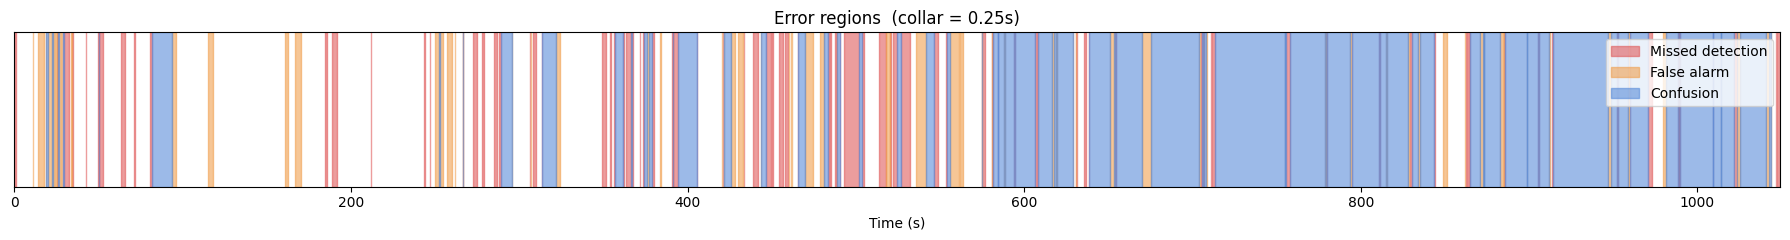

In [17]:
from pyannote.core import Timeline

def get_error_regions(ref: Annotation, hyp: Annotation, collar: float = 0.0):
    """Return three Timelines: missed, false_alarm, confusion."""
    def apply_collar(ann: Annotation, c: float) -> Annotation:
        if c == 0.0:
            return ann
        result = Annotation(uri=ann.uri)
        for seg, track, label in ann.itertracks(yield_label=True):
            trimmed = Segment(seg.start + c, seg.end - c)
            if trimmed.duration > 0:
                result[trimmed, track] = label
        return result

    ref_c = apply_collar(ref, collar)
    hyp_c = apply_collar(hyp, collar)

    ref_timeline = ref_c.get_timeline().support()
    hyp_timeline = hyp_c.get_timeline().support()

    missed      = ref_timeline.extrude(hyp_timeline)
    false_alarm = hyp_timeline.extrude(ref_timeline)

    metric_tmp = DiarizationErrorRate(collar=0.0)
    mapping    = metric_tmp.optimal_mapping(ref_c, hyp_c)
    hyp_mapped = hyp_c.rename_labels(mapping=mapping)

    confusion_segs = []
    for seg in ref_timeline:
        for sub in hyp_timeline:
            inter = seg & sub
            if not inter:
                continue
            ref_spks = set(ref_c.crop(inter).labels())
            hyp_spks = set(hyp_mapped.crop(inter).labels())
            if ref_spks != hyp_spks and ref_spks and hyp_spks:
                confusion_segs.append(inter)

    confusion = Timeline(confusion_segs).support()
    return missed, false_alarm, confusion


missed, false_alarm, confusion = get_error_regions(ref, hyp, collar=COLLAR)

fig, ax = plt.subplots(figsize=(18, 2.5))

for seg in missed:
    ax.axvspan(seg.start, seg.end, ymin=0, ymax=1, color="#e05c5c", alpha=0.6, label="_")
for seg in false_alarm:
    ax.axvspan(seg.start, seg.end, ymin=0, ymax=1, color="#f0a050", alpha=0.6, label="_")
for seg in confusion:
    ax.axvspan(seg.start, seg.end, ymin=0, ymax=1, color="#5b8dd9", alpha=0.6, label="_")

legend_patches = [
    mpatches.Patch(color="#e05c5c", alpha=0.6, label="Missed detection"),
    mpatches.Patch(color="#f0a050", alpha=0.6, label="False alarm"),
    mpatches.Patch(color="#5b8dd9", alpha=0.6, label="Confusion"),
]
ax.legend(handles=legend_patches, loc="upper right")
ax.set_xlabel("Time (s)")
ax.set_title(f"Error regions  (collar = {COLLAR}s)")
ax.set_yticks([])
ax.set_xlim(ref.get_timeline().extent().start,
            ref.get_timeline().extent().end)
plt.tight_layout()
plt.show()